In [1]:
!mkdir ~/.kaggle

In [9]:
!cp kaggle.json ~/.kaggle/

In [10]:
!chmod 600 ~/.kaggle/kaggle.json

In [11]:
!kaggle competitions download -c dogs-vs-cats

100% 812M/812M [00:04<00:00, 203MB/s]



In [12]:
!unzip -qq dogs-vs-cats.zip

In [13]:
!unzip -qq train.zip

In [14]:
import os, shutil, pathlib
original_dir = pathlib.Path("train")
new_base_dir = pathlib.Path("cats_vs_dogs_small")

In [16]:
def make_subset(subset_name, start_index, end_index):
  for category in ("cat", "dog"):
    dir = new_base_dir / subset_name / category
    os.makedirs(dir)
    fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]
    for fname in fnames:
      shutil.copyfile(src=original_dir/fname,  dst=dir/fname)

In [17]:
make_subset("train", start_index=0, end_index=1000)
make_subset("validation", start_index=1000, end_index=1500)
make_subset("test", start_index=1500, end_index=2500)

In [18]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [19]:
model.compile(loss="binary_crossentropy", optimizer="rmsprop", metrics=["accuracy"])

In [20]:
from tensorflow.keras.utils import image_dataset_from_directory

In [21]:
train_dataset = image_dataset_from_directory(
                                              new_base_dir / "train",
                                              image_size=(180, 180),
                                              batch_size=32)
validation_dataset = image_dataset_from_directory(
                                              new_base_dir / "validation",
                                              image_size=(180, 180),
                                              batch_size=32)
test_dataset = image_dataset_from_directory(
                                              new_base_dir / "test",
                                              image_size=(180, 180),
                                              batch_size=32)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [24]:
callbacks = [
              keras.callbacks.ModelCheckpoint(
              filepath="convnet_from_scratch.keras",
              save_best_only=True,
              monitor="val_accuracy")
              ]

In [25]:
history = model.fit(
                      train_dataset,
                      epochs=30,
                      validation_data=validation_dataset,
                      callbacks=callbacks)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.9835 - loss: 0.0554 - val_accuracy: 0.7340 - val_loss: 1.9974
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.9900 - loss: 0.0271 - val_accuracy: 0.7370 - val_loss: 2.4329
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9830 - loss: 0.0666 - val_accuracy: 0.7250 - val_loss: 2.3706
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.9870 - loss: 0.0443 - val_accuracy: 0.7410 - val_loss: 2.2201
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.9930 - loss: 0.0350 - val_accuracy: 0.7300 - val_loss: 2.6685
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9900 - loss: 0.0346 - val_accuracy: 0.7330 - val_loss: 2.2107
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.9930 - loss: 0.0283 - val_accuracy: 0.6740 - val_loss: 3.9239
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.9895 - loss: 0.0315 - val_accuracy: 0.7250 - v

In [26]:
test_model = keras.models.load_model("convnet_from_scratch.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.7310 - loss: 2.8475
Test accuracy: 0.731


In [27]:
data_augmentation = keras.Sequential(
 [
          layers.RandomFlip("horizontal"),
          layers.RandomRotation(0.1),
          layers.RandomZoom(0.2),
 ]
)

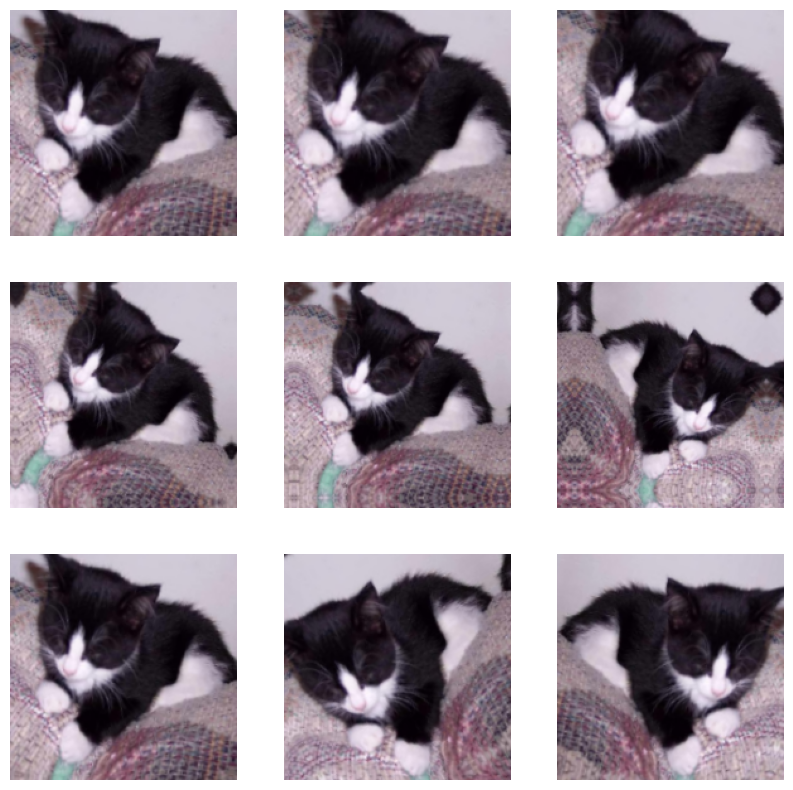

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
for images, _ in train_dataset.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

In [33]:
inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(loss="binary_crossentropy", optimizer="rmsprop", metrics=["accuracy"])

In [34]:
callbacks = [
 keras.callbacks.ModelCheckpoint(
 filepath="convnet_from_scratch_with_augmentation.keras",
 save_best_only=True,
 monitor="val_loss")
]
history = model.fit(
                  train_dataset,
                  epochs=100,
                  validation_data=validation_dataset,
                  callbacks=callbacks)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.5045 - loss: 0.7009 - val_accuracy: 0.5300 - val_loss: 0.6928
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.5230 - loss: 0.6932 - val_accuracy: 0.5670 - val_loss: 0.6900
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.5260 - loss: 0.6913 - val_accuracy: 0.5000 - val_loss: 0.6963
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.5690 - loss: 0.6822 - val_accuracy: 0.6140 - val_loss: 0.6592
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.6110 - loss: 0.6724 - val_accuracy: 0.6800 - val_loss: 0.6323
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.6355 - loss: 0.6483 - val_accuracy: 0.6070 - val_loss: 0.6403
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.6525 - loss: 0.6279 - val_accuracy: 0.6600 - val_loss: 0.6218
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.6645 - loss: 0.6124 - val_accuracy: 0.

In [36]:
#  "convnet_from_scratch_with_augmentation.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.7310 - loss: 2.8475
Test accuracy: 0.731
